# 📓 Cas d'usage IA — [TITRE DU PROJET]

**Auteur·e** : `Romain Busuttil`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `16/07/2026`  
**Dernière mise à jour** : `16/07/2026`

---

## 0. Imports & configuration

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Imports ML (à activer au fur et à mesure)
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

In [2]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv"
DATASET_SOURCE = "../data"
DATASET_VERSION = "2026-07-08"

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-07-21T11:02
Python       : 3.11.9
NumPy        : 1.26.4
Pandas       : 2.2.2
Git commit   : 8caed83
Dataset      : dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv (source=../data, version=2026-07-08)


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une agence nationale de l’emploi (ex : France Travail), donc c'est un service public chargé de la politique de l’emploi. Elle accompagne les demandeurs d’emploi dans leur retour à l’activité en mobilisant des dispositifs adaptés (formations, suivi renforcé, aides). Son secteur est régulé, avec des obligations de neutralité, d’égalité de traitement et de transparence, encadrées par le RGPD et l’AI Act.
Son problème métier principal est d’orienter rapidement et efficacement chaque usager dès le premier entretien, malgré un volume élevé de dossiers et une forte hétérogénéité des profils. Une mauvaise orientation, notamment pour les personnes à risque de chômage longue durée, peut entraîner uncoût humain et financier élevé.
Le recours à l’intelligence artificielle est motivé par la volonté d’identifier rapidement les situations à risque, et d’optimiser l’allocation des ressources d’accompagnement, et donc assister les conseillers dans leur prise de décision.

### 1.2 Énoncé du problème IA

Prédire le délai de retour à l’emploi (rapide <6 mois, moyen 6-12 mois, long >12 mois) à partir de données multimodales comprenant des variables tabulaires (âge, diplôme, expérience, statut, géographie) et du texte libre issu de la synthèse d’entretien.
Prédire la classe de retour à l’emploi (0, 1 ou 2) à partir des caractéristiques individuelles et du contenu textuel décrivant la situation de l’usager.

### 1.3 Bénéficiaires & impacts

Direct : Les conseillers de l’agence de l’emploi, qui s’appuient sur les prédictions pour orienter les demandeurs d’emploi, prioriser les suivis et décider des dispositifs d’accompagnement.
Indirect : Les demandeurs d’emploi, qui subissent directement les conséquences des prédictions (type d’accompagnement, intensité du suivi, accès à certaines aides).

### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire le délai moyen de retour à l’emploi pour les profils à risque | -20% |  |  |
| Modèle | Accuracy, F1-score macro et Matrice de confusion | Accuracy ≥ 80%, F1-score macro ≥ 0.75, Recall ≥ 85% pour classe 2 |  | … |
| Opérationnel | Temps de réponse API en production | < 250 ms |  | … |

Les cibles initiales n'étant pas définies dans le sujet, elles sont définies à partir d’objectifs métier ambitieux. Elles seront ensuite potentiellement révisées après l'analyse exploratoire des données.

### 1.5 Risques éthiques & réglementaires anticipés

**🔐 Variables sensibles identifiées** :
- `nationalite_hors_ue` : données sensible pouvant entrainer une risque de discrimination.
- `code_insee_commune` : peut donner des informations sur l'origine sociale, le niveau de vie. C'est une variable proxy.
- `age` : critère de discrimination (séniors / jeunes)
- `est_allocataire` : critère de discrimination (précarité)
- `synthese_entretien` : texte libre qui pourrait contenir des informations personnelle (situation familiale, état de santé, ...)

**Biais potentiels** :
- Les synthèses des conseillers peuvent déjà contenir des biais (anticipation des difficultés a retrouver un travail).
- Les données proviennent d'une agence spécifique et donc non représentatives du territoire national.
- Corrélation entre `nationalite_hors_ue` et `code_insee_commune` qui donnerait des informations sur les quartiers défavorisés.
- Certaines populations sous-représentées dans les 2500 observations (exemple `nationalite_hors_ue`, `age`, `niveau_diplome`).
- Classe déséquilibré : une catégorie pas prise en compte par le modèle.

**RGPD** :
- Pseudonymisation : remplacer `usager_id` par un hash (ex : SHA-256) pour éviter la ré-identification.
- Droit à l'oubli : permettre aux usagers de supprimer leurs données après 3 ans.
- Minimisation des données : ne garder que les variables nécessaires
- Analyse d'impact : obligatoire pour les traitements à haut risque.

**AI Act** :
Cas d’usage potentiellement à haut risque car lié à l’emploi et à l’accès à des services publics.
Nécessité de supervision humaine, documentation, robustesse, gestion des logs et suivi des dérives.

**Droit sectoriel** :
Attention à la discrimination (`nationalite_hors_ue`, `age`, `code_insee_commune`)

### 1.6 📝 Synthèse cadrage

Le projet vise à aider une agence publique de l’emploi à mieux orienter les demandeurs d’emploi dès le premier entretien.  
La tâche IA retenue est une classification en 3 classes (<6 mois*, *6-12 mois*, *>12 mois) du délai de retour à l’emploi à partir de données tabulaires et de texte libre.  
Le critère de succès dominant est la qualité de détection des profils à risque, avec un bon F1-score macro et une matrice de confusion équilibrée.  
Le principal risque éthique identifié est la discrimination indirecte via des variables sensibles ou proxy, dans un contexte de traitement de données personnelles.

---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Fichier fourni examen :  dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143)local | 2 500 lignes × 10 colonnes | `.csv` | Lecture seule | `08/07/2026` |


In [3]:
# 2.2 Chargement
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv")
df.shape, df.columns.tolist()

((2500, 10),
 ['usager_id',
  'age',
  'niveau_diplome',
  'anciennete_poste_ans',
  'code_rome_vise',
  'code_insee_commune',
  'est_allocataire',
  'nationalite_hors_ue',
  'synthese_entretien',
  'classe_retour_emploi'])

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | IdenIdentifiant unique du demandeur d'emploi | catégoriel (ID) | `ID_0000` … `ID_2499` | ❌ | ✅ (pseudonyme à hasher si utilisé) |
| `age` | Âge de l'usager en années | numérique (entier) | 18 – 63 ans | ❌ | ✅ (discrimination âge) |
| `niveau_diplome` | Plus haut niveau de diplôme obtenu (Donnée manquante potentielle) | catégoriel (ordinal) | `Sans diplôme`, `Bac`, `Bac+2`, `Bac+5` | ❌ | ❌ |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | numérique (continue) | 0,0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | catégoriel (nominal) | codes ROME (ex : `D1503`, `G1302`, …) | ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | catégoriel (nominal) | codes INSEE communes françaises | ❌ | ✅ (variable proxy) |
| `est_allocataire` | Statut d'indemnisation de l'usager | binaire | 0 = non, 1 = oui | ❌ | ✅ (indicateur de précarité) |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | binaire | 0 = UE, 1 = hors UE | ❌ | ✅ (donnée sensible RGPD) |
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte libre | variable (phrases courtes) | ❌ | ✅ (peut contenir données personnelles) |
| `classe_retour_emploi` | **Délai de retour à l'emploi (variable cible)** | catégoriel (ordinal) | 0 = Rapide <6 mois, 1 = Moyen 6–12 mois, 2 = Long >12 mois | ✅ | ❌ |

### 2.4 📝 Synthèse acquisition

Le jeu de données provient d'un fichier CSV fourni dans le cadre de l'examen CISIA. Il contient **2 500 observations** et **10 colonnes** : 9 features (tabulaires + texte libre) et 1 variable cible de classification à 3 classes.  
Plusieurs variables sensibles ont été identifiées dès cette étape (`nationalite_hors_ue`, `age`, `code_insee_commune`, `synthese_entretien`, `est_allocataire`), nécessitant une attention particulière aux biais et au respect du RGPD.


---
## 3. Exploration & analyse des données (EDA)

### 3.1 Premier coup d'œil

In [ ]:
# Aperçu des premières lignes
display(df.head())
# Résumé structurel
df.info()
# Statistiques descriptives
df.describe(include="all")

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
count,2500,2378.000000,2416,2500.000000,2500,2500,2456.000000,2500.000000,2419,2500.000000
unique,2500,NaN,4,NaN,50,2407,NaN,NaN,9,NaN
top,ID_0000,NaN,Bac,NaN,H1206,34045,NaN,NaN,Compétences à réactualiser sur les outils numé...,NaN
freq,1,NaN,966,NaN,71,3,NaN,NaN,338,NaN
mean,NaN,40.566442,NaN,2.971600,NaN,NaN,0.595684,0.118000,NaN,0.806400
std,NaN,13.225242,NaN,2.979548,NaN,NaN,0.490859,0.322673,NaN,0.719671
min,NaN,18.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,29.000000,NaN,0.800000,NaN,NaN,0.000000,0.000000,NaN,0.000000
50%,NaN,41.000000,NaN,2.000000,NaN,NaN,1.000000,0.000000,NaN,1.000000
75%,NaN,52.000000,NaN,4.100000,NaN,NaN,1.000000,0.000000,NaN,1.000000


- Données manquantes : `age` (4,9%), `niveau_diplome` (3,4%), `synthese_entretien` (3,2%) => attention seule la colonne `niveau_diplome` est autorisée à être manquante d'après l'énoncé.
- Cible déséquilibrée : une moyenne de 0.81 pour des valeurs de 0, 1 ou 2 montre un léger déséquilibre pour la classe 2 (long >12 mois)
- Texte redondant : seulement 9 synthèses uniques pour 2419 non-nulls
- Géographie potentiellement disparate : 2407 communes pour 2500 lignes
- Allocataires : 59,6% ont une allocation (potentiel léger déséquilibre)
- Code INSEE à vérifier (code sur 4 chiffres possible? 0 au début tronqué?)
- `usager_id` unique : pas de doublon d'ID.

---

### 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

In [7]:
# Valeurs manquantes
display(df.isna().sum())
# Ligne en doublon
df.duplicated().sum()

usager_id                 0
age                     122
niveau_diplome           84
anciennete_poste_ans      0
code_rome_vise            0
code_insee_commune        0
est_allocataire          44
nationalite_hors_ue       0
synthese_entretien       81
classe_retour_emploi      0
dtype: int64

0

**Manquants**
- `age` : **4,9%** de valeurs manquantes (point de vigilance, à traiter avant modélisation).
- `niveau_diplome` : **3,4%** de valeurs manquantes (à remplacer par `"Inconnu"` ou valeur majoritaire).
- `synthese_entretien` : **3,2%** de valeurs manquantes (à remplacer par chaîne vide ou `"synthese_absente"`).

**Doublons**
- Aucun doublon de ligne détecté.

**Valeurs aberrantes / cohérence**
- `age` (18–63) : plage plausible, pas d’outlier évident.
- `anciennete_poste_ans` (0–22,6) : valeurs plausibles, mais à contrôler avec une règle de cohérence (`age` - `anciennete_poste_ans <= 6`).
- `code_insee_commune` : vigilance sur le type (`str`) pour éviter la perte des zéros en tête.

**Conclusion**
La qualité globale est exploitable, mais nécessite un prétraitement ciblé : imputation des manquants, contrôles de cohérence métier, et sécurisation des variables sensibles/proxy avant entraînement.

In [26]:
# Vérification de cohérence : ancienneté compatible avec âge et années d'études
# finalement sans les études car il peut y avoir de l'alternance ou des parcours atypiques qui pourraient être pris en compte dans l'ancienneté
# On regarde donc juste l'âge et l'ancienneté dans le poste qui doit être <= 15 ans (âge légal pour travailler : 16 ans)
# 15 ans car les ages sont arrondis
mask_incoherent = (df["age"] - df["anciennete_poste_ans"]) <= 15

incoherences = df.loc[mask_incoherent, ["usager_id", "age", "niveau_diplome", "anciennete_poste_ans", "classe_retour_emploi"]]

print(f"Nombre de lignes incohérentes : {len(incoherences)}")
display(incoherences.head(10))

Nombre de lignes incohérentes : 74


,usager_id,age,niveau_diplome,anciennete_poste_ans,classe_retour_emploi
89,ID_0089,18.0,Bac,7.0,1
94,ID_0094,18.0,Bac,5.2,0
129,ID_0129,18.0,Bac,5.5,0
156,ID_0156,24.0,Bac+2,13.7,0
220,ID_0220,22.0,Bac,8.9,1
302,ID_0302,20.0,Bac,8.1,1
332,ID_0332,23.0,Sans diplôme,8.2,1
358,ID_0358,19.0,Bac+5,5.6,0
380,ID_0380,18.0,Bac+5,3.1,2
390,ID_0390,19.0,Sans diplôme,4.2,1


**Conclusion sur les incohérences entre l'âge et l'ancienneté**

La règle de contrôle identifie **74 lignes** (≈ **3,0%** du dataset) comme potentiellement incohérentes.  
Le volume est non négligeable mais reste limité : voir quel prétraitement appliquer.

---

### 3.3 Distribution des variables (numériques + catégorielles)

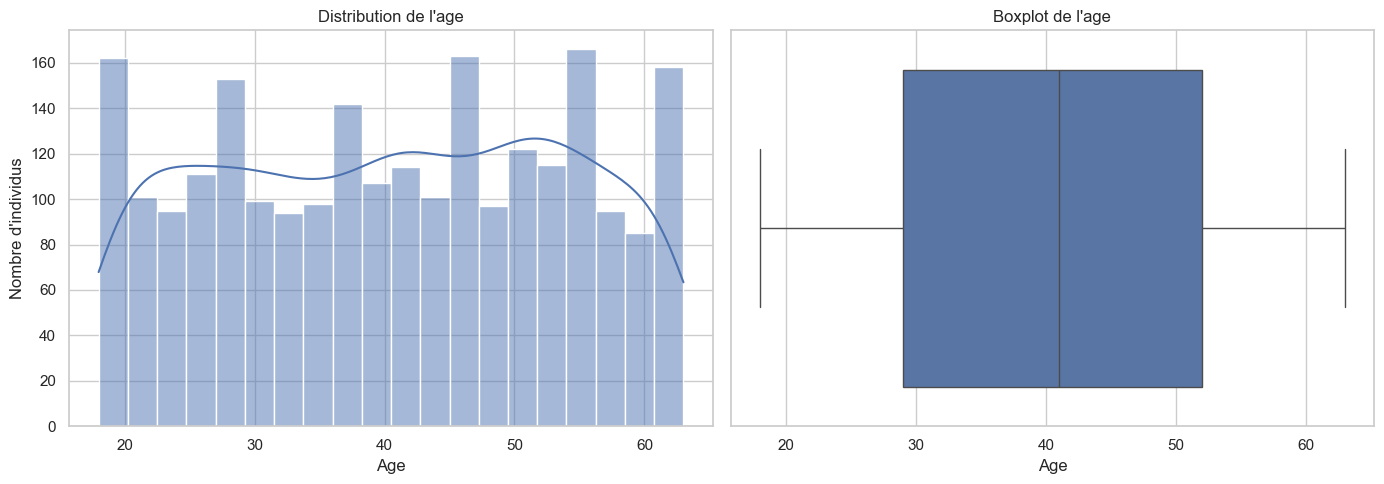

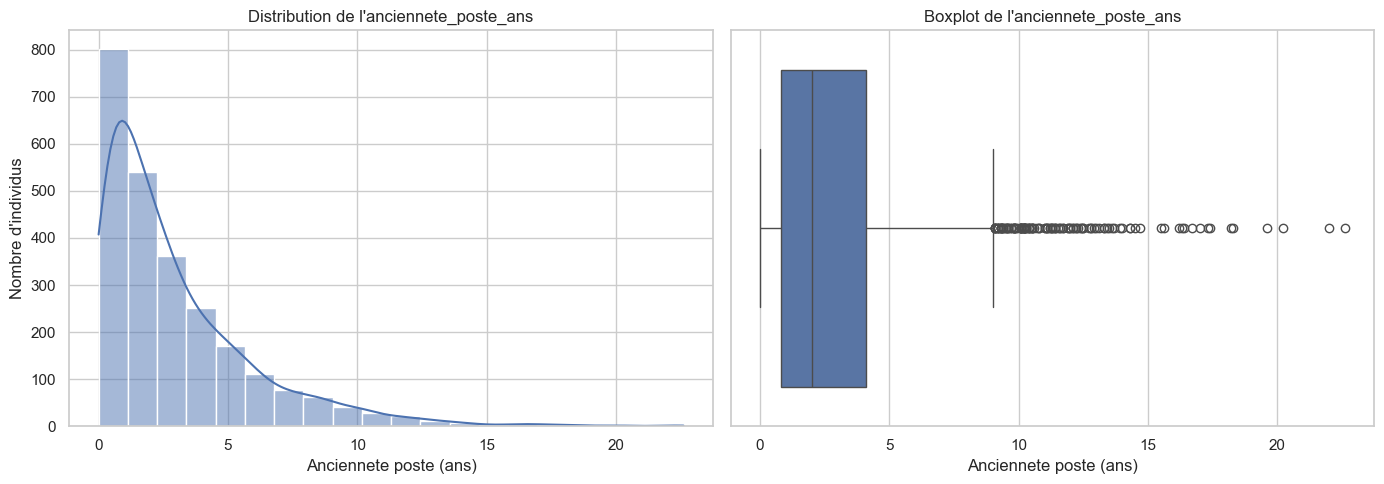

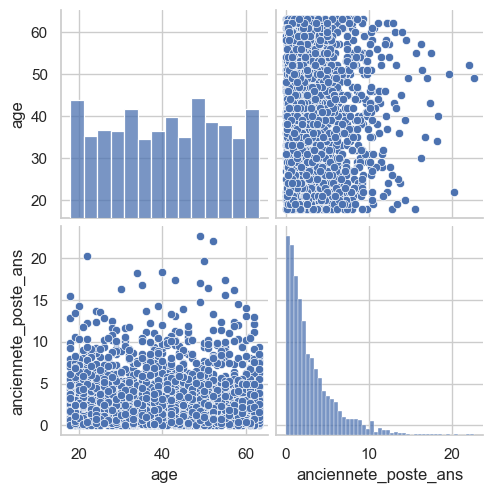

In [45]:
# Variables cibles => histogramme et boxplot
# Distribution de l'age : histo et boxplot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution de l'age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Nombre d'individus")

sns.boxplot(data=df, x="age", ax=axes[1])
axes[1].set_title("Boxplot de l'age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

# distribution de l'anciennete_poste_ans
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution de l'anciennete_poste_ans")
axes[0].set_xlabel("Anciennete poste (ans)")
axes[0].set_ylabel("Nombre d'individus")

sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1])
axes[1].set_title("Boxplot de l'anciennete_poste_ans")
axes[1].set_xlabel("Anciennete poste (ans)")

plt.tight_layout()
plt.show()

# Relations entre variables numériques
sns.pairplot(df, vars=["age", "anciennete_poste_ans"])


In [ ]:
# Variables catégorielles => value_counts() (ou countplot)
#TODO pour niveau_diplome, est_allocataire, nationalite_hors_ue, classe_retour_emploi

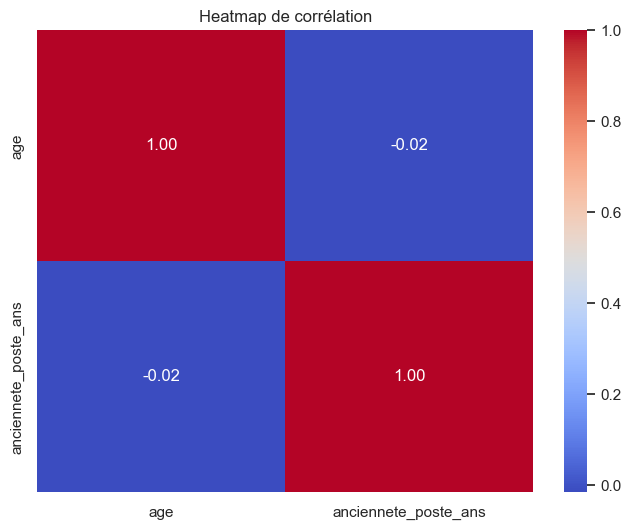

In [46]:
# Relations entre variables numériques
# Heatmap de corrélation
corr = df[["age", "anciennete_poste_ans"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de corrélation")
plt.show()

**Conclusion**
TODO

### 3.4 Variable cible : équilibre des classes / distribution

In [ ]:
df["classe_retour_emploi"].value_counts(normalize=True)

classe_retour_emploi
1    0.4448
0    0.3744
2    0.1808
Name: proportion, dtype: float64

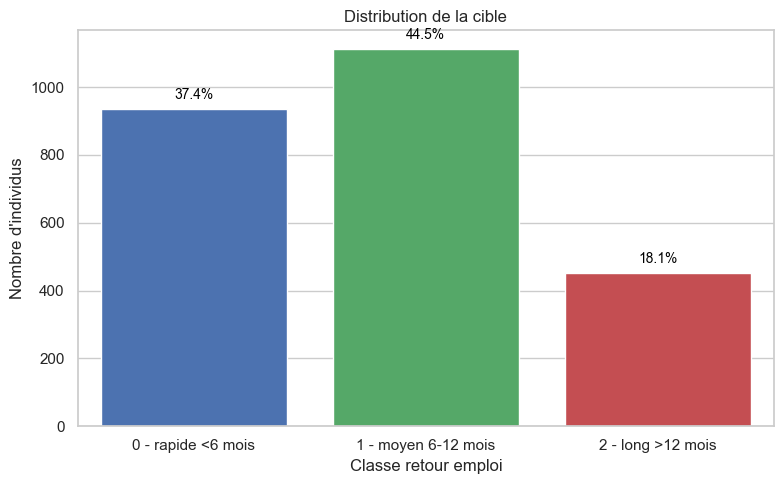

In [39]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
repartition = sns.countplot(data=df, x="classe_retour_emploi", order=[0, 1, 2])
# 3 couleurs (une par classe)
colors = ["#4C72B0", "#55A868", "#C44E52"]
for i, p in enumerate(repartition.patches):
    p.set_facecolor(colors[i % len(colors)])
plt.title("Distribution de la cible")
plt.xlabel("Classe retour emploi")
# On met les labels
plt.xticks([0, 1, 2], ["0 - rapide <6 mois", "1 - moyen 6-12 mois", "2 - long >12 mois"])
plt.ylabel("Nombre d'individus")
# ajout des pourcentages sur les barres
total = len(df)
for p in repartition.patches:
    height = p.get_height()
    percentage = f"{height / total * 100:.1f}%"
    repartition.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha="center", va="bottom", fontsize=10, color="black", xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.show()

On observe un léger déséquilibre de la cible sur la classe 2 (long >12 mois), ce qui pourrait entrainer un biais.
On peut pour éviter ce biais :
- utiliser un split stratifié (`train_test_split(..., stratify=y)`)
- suivre des métriques adaptées (F1 macro, recall par classe, matrice de confusion)
- tester un rééquilibrage si besoin (`class_weight="balanced"`)